# 🔷 LOSS FUNCTION (0.1)

Device: cuda
Epoch 1/100 - Loss:112.3738 Train Acc:83.52% Val Acc:81.18% Train F1:0.8351 Val F1:0.8104
Epoch 2/100 - Loss:95.3246 Train Acc:89.27% Val Acc:90.15% Train F1:0.8926 Val F1:0.9012
Epoch 3/100 - Loss:90.3707 Train Acc:90.69% Val Acc:50.55% Train F1:0.9069 Val F1:0.3454
Epoch 4/100 - Loss:87.1622 Train Acc:90.66% Val Acc:54.38% Train F1:0.9066 Val F1:0.4267
Epoch 5/100 - Loss:81.9926 Train Acc:92.96% Val Acc:83.26% Train F1:0.9296 Val F1:0.8289
Epoch 6/100 - Loss:79.4092 Train Acc:93.73% Val Acc:93.44% Train F1:0.9373 Val F1:0.9344
Epoch 7/100 - Loss:79.2331 Train Acc:93.40% Val Acc:91.58% Train F1:0.9340 Val F1:0.9154
Epoch 8/100 - Loss:75.3370 Train Acc:94.11% Val Acc:93.11% Train F1:0.9411 Val F1:0.9311
Epoch 9/100 - Loss:75.2167 Train Acc:94.09% Val Acc:94.42% Train F1:0.9408 Val F1:0.9442
Epoch 10/100 - Loss:74.2333 Train Acc:94.74% Val Acc:89.06% Train F1:0.9474 Val F1:0.8897
Epoch 11/100 - Loss:71.1459 Train Acc:95.37% Val Acc:92.45% Train F1:0.9537 Val F1:0.9242
Epoch

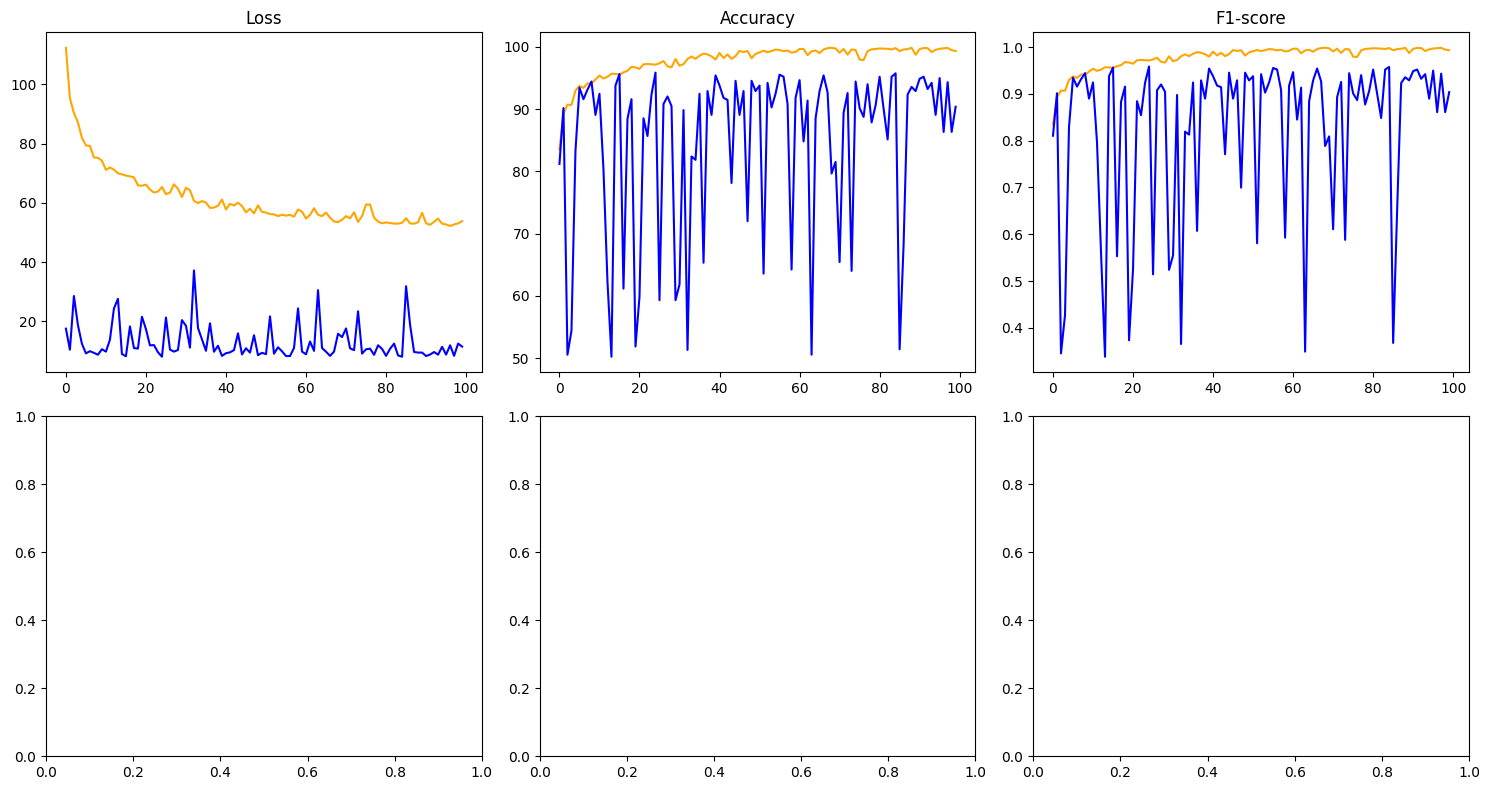

In [ ]:
# ============================================================
# EEG FEW-SHOT LEARNING FRAMEWORK
# Sobel + Attention + KAN + Deep Supervision
# ============================================================

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from datetime import datetime

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve
)

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# LOAD DATA
# ============================================================

mat = sio.loadmat("SEED_VIG.mat")

X = mat["EEGsample"].astype(np.float32)
y = mat["substate"].squeeze()

X = (X - X.mean()) / (X.std() + 1e-6)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================================
# DATASET
# ============================================================

class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

train_loader = DataLoader(EEGDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader   = DataLoader(EEGDataset(X_val, y_val), batch_size=32, shuffle=False)

# ============================================================
# SOBEL PROJECTION
# ============================================================

class Sobel1D(nn.Module):
    def __init__(self):
        super().__init__()
        k = torch.tensor([[[-1, 0, 1]]], dtype=torch.float32)
        self.weight = nn.Parameter(k, requires_grad=False)

    def forward(self, x):
        B, C, T = x.shape
        out = []
        for c in range(C):
            out.append(F.conv1d(x[:, c:c+1], self.weight, padding=1))
        return torch.cat(out, dim=1).abs()

# ============================================================
# ATTENTION
# ============================================================

class Attention1D(nn.Module):
    def __init__(self, C, r=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(C, C // r)
        self.fc2 = nn.Linear(C // r, C)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        B, C, T = x.shape
        y = self.pool(x).view(B, C)
        y = F.relu(self.fc1(y))
        y = self.sigmoid(self.fc2(y)).view(B, C, 1)
        return x * y

# ============================================================
# KAN MIXER
# ============================================================

class KAN(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim * 2)
        self.fc2 = nn.Linear(dim * 2, dim)
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        r = x
        x = self.norm(x)
        x = F.gelu(self.fc1(x))
        x = self.fc2(x)
        return x + r

# ============================================================
# ENCODER
# ============================================================

class Encoder(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.sobel = Sobel1D()

        self.conv1 = nn.Conv1d(17, 32, 5, padding=2)
        self.conv2 = nn.Conv1d(32, 64, 5, padding=2)
        self.conv3 = nn.Conv1d(64, 128, 5, padding=2)

        self.bn1 = nn.BatchNorm1d(32)
        self.bn2 = nn.BatchNorm1d(64)
        self.bn3 = nn.BatchNorm1d(128)

        self.att1 = Attention1D(32)
        self.att2 = Attention1D(64)
        self.att3 = Attention1D(128)

        self.pool = nn.MaxPool1d(2)

        self.kan = KAN(128)

        self.ds1 = nn.Linear(32, num_classes)
        self.ds2 = nn.Linear(64, num_classes)
        self.ds3 = nn.Linear(128, num_classes)

    def forward(self, x):

        x = x + self.sobel(x)

        x1 = self.pool(self.att1(F.relu(self.bn1(self.conv1(x)))))
        x2 = self.pool(self.att2(F.relu(self.bn2(self.conv2(x1)))))
        x3 = self.pool(self.att3(F.relu(self.bn3(self.conv3(x2)))))

        f1 = F.adaptive_avg_pool1d(x1, 1).squeeze(-1)
        f2 = F.adaptive_avg_pool1d(x2, 1).squeeze(-1)
        f3 = F.adaptive_avg_pool1d(x3, 1).squeeze(-1)

        f3 = self.kan(f3)

        return f3, self.ds1(f1), self.ds2(f2), self.ds3(f3)

# ============================================================
# MODEL
# ============================================================

num_classes = len(np.unique(y))

class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = Encoder(num_classes)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        f, d1, d2, d3 = self.enc(x)
        return self.fc(f), [d1, d2, d3]

model = Model().to(device)

# ============================================================
# LOSS + OPT
# ============================================================

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ============================================================
# HISTORY
# ============================================================

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "train_f1": [],
    "val_f1": []
}

# ============================================================
# TRAINING
# ============================================================

start_time = datetime.now()
num_epochs = 100

for epoch in range(num_epochs):

    # ================= TRAIN =================
    model.train()
    train_p, train_y = [], []
    train_loss = 0

    for x, yb in train_loader:
        x, yb = x.to(device), yb.to(device)

        optimizer.zero_grad()

        logits, ds = model(x)

        loss = criterion(logits, yb)
        for d in ds:
            loss += 0.3 * criterion(d, yb)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        train_p.extend(torch.argmax(logits, 1).cpu().numpy())
        train_y.extend(yb.cpu().numpy())

    # ================= VAL =================
    model.eval()
    val_p, val_y = [], []
    val_loss = 0

    with torch.no_grad():
        for x, yb in val_loader:
            x, yb = x.to(device), yb.to(device)

            logits, _ = model(x)

            loss = criterion(logits, yb)
            val_loss += loss.item()

            val_p.extend(torch.argmax(logits, 1).cpu().numpy())
            val_y.extend(yb.cpu().numpy())

    # ================= METRICS =================
    tr_acc = accuracy_score(train_y, train_p) * 100
    va_acc = accuracy_score(val_y, val_p) * 100

    tr_f1 = f1_score(train_y, train_p, average='weighted')
    va_f1 = f1_score(val_y, val_p, average='weighted')

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)
    history["train_f1"].append(tr_f1)
    history["val_f1"].append(va_f1)

    print(f"Epoch {epoch+1}/{num_epochs} - "
          f"Loss:{train_loss:.4f} "
          f"Train Acc:{tr_acc:.2f}% "
          f"Val Acc:{va_acc:.2f}% "
          f"Train F1:{tr_f1:.4f} "
          f"Val F1:{va_f1:.4f}")

print("Training time:", datetime.now() - start_time)

# ============================================================
# VISUALIZATION (BLUE=VAL, ORANGE=TRAIN)
# ============================================================

epochs = range(num_epochs)

fig, ax = plt.subplots(2, 3, figsize=(15, 8))

# LOSS
ax[0,0].plot(history["train_loss"], color='orange')
ax[0,0].plot(history["val_loss"], color='blue')
ax[0,0].set_title("Loss")

# ACC
ax[0,1].plot(history["train_acc"], color='orange')
ax[0,1].plot(history["val_acc"], color='blue')
ax[0,1].set_title("Accuracy")

# F1
ax[0,2].plot(history["train_f1"], color='orange')
ax[0,2].plot(history["val_f1"], color='blue')
ax[0,2].set_title("F1-score")

plt.tight_layout()
plt.show()

# **Loss Function (0.2)**

Device: cuda
Epoch 1/100 - Loss:121.2661 Train Acc:83.19% Val Acc:87.53% Train F1:0.8319 Val F1:0.8746
Epoch 2/100 - Loss:108.6885 Train Acc:89.84% Val Acc:69.26% Train F1:0.8984 Val F1:0.6683
Epoch 3/100 - Loss:104.2424 Train Acc:91.62% Val Acc:77.24% Train F1:0.9162 Val F1:0.7615
Epoch 4/100 - Loss:101.5403 Train Acc:91.89% Val Acc:84.14% Train F1:0.9189 Val F1:0.8391
Epoch 5/100 - Loss:98.3086 Train Acc:92.80% Val Acc:91.90% Train F1:0.9280 Val F1:0.9189
Epoch 6/100 - Loss:97.0460 Train Acc:93.18% Val Acc:69.80% Train F1:0.9318 Val F1:0.6753
Epoch 7/100 - Loss:95.6846 Train Acc:93.92% Val Acc:62.91% Train F1:0.9392 Val F1:0.5723
Epoch 8/100 - Loss:94.8828 Train Acc:93.51% Val Acc:89.39% Train F1:0.9351 Val F1:0.8931
Epoch 9/100 - Loss:96.5665 Train Acc:93.48% Val Acc:93.54% Train F1:0.9348 Val F1:0.9354
Epoch 10/100 - Loss:93.1074 Train Acc:94.69% Val Acc:93.00% Train F1:0.9469 Val F1:0.9299
Epoch 11/100 - Loss:92.1197 Train Acc:94.74% Val Acc:86.43% Train F1:0.9474 Val F1:0.8628
Ep

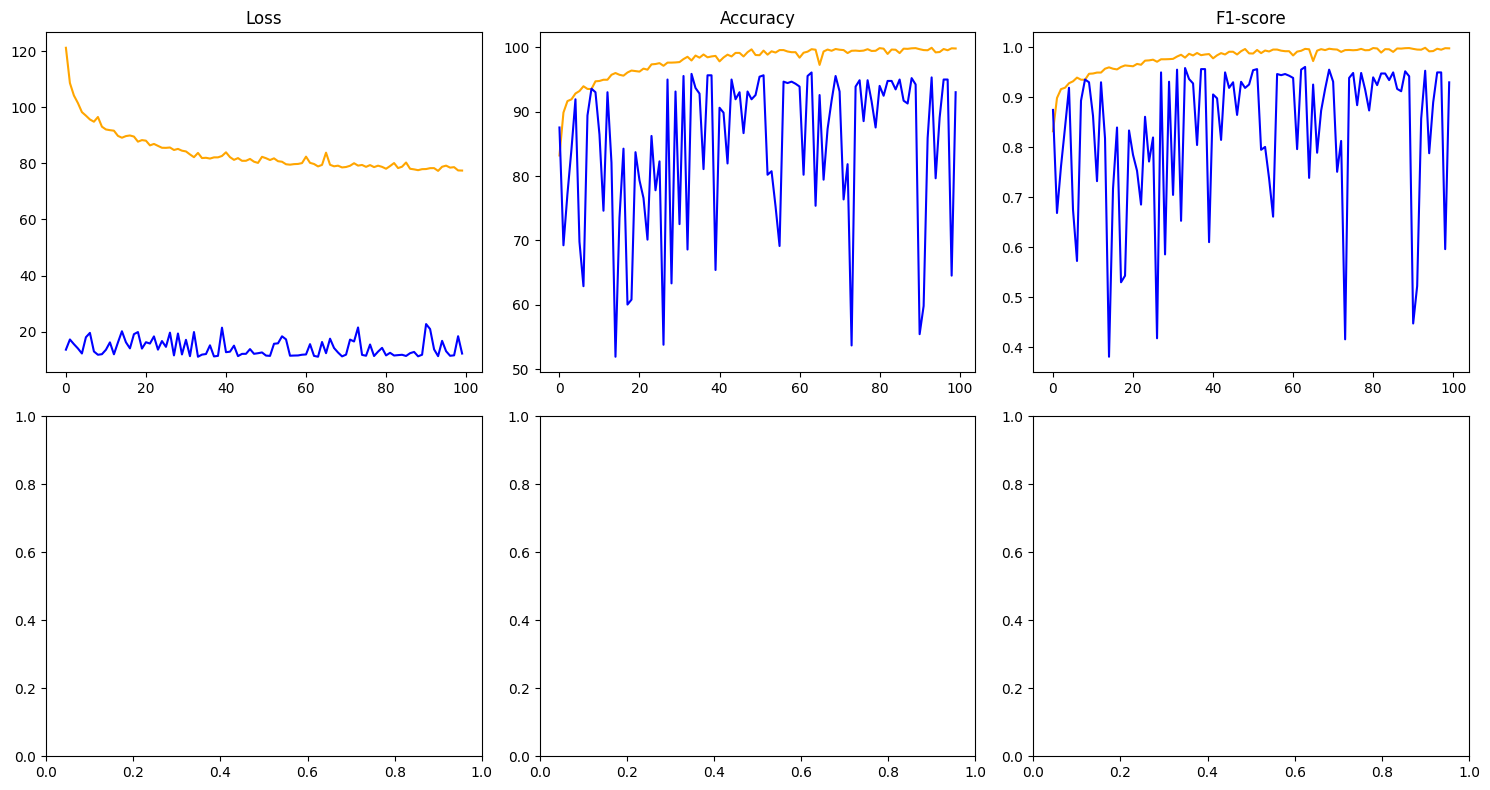

In [ ]:
# ============================================================
# EEG FEW-SHOT LEARNING FRAMEWORK
# Sobel + Attention + KAN + Deep Supervision
# Train/Validation + ROC + PR + IEEE Figures
# ============================================================

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from datetime import datetime

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve
)

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# LOAD DATA
# ============================================================

mat = sio.loadmat("SEED_VIG.mat")

X = mat["EEGsample"].astype(np.float32)
y = mat["substate"].squeeze()

X = (X - X.mean()) / (X.std() + 1e-6)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================================
# DATASET
# ============================================================

class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

train_loader = DataLoader(EEGDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader   = DataLoader(EEGDataset(X_val, y_val), batch_size=32, shuffle=False)

# ============================================================
# SOBEL PROJECTION
# ============================================================

class Sobel1D(nn.Module):
    def __init__(self):
        super().__init__()
        k = torch.tensor([[[-1, 0, 1]]], dtype=torch.float32)
        self.weight = nn.Parameter(k, requires_grad=False)

    def forward(self, x):
        B, C, T = x.shape
        out = []
        for c in range(C):
            out.append(F.conv1d(x[:, c:c+1], self.weight, padding=1))
        return torch.cat(out, dim=1).abs()

# ============================================================
# ATTENTION
# ============================================================

class Attention1D(nn.Module):
    def __init__(self, C, r=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(C, C // r)
        self.fc2 = nn.Linear(C // r, C)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        B, C, T = x.shape
        y = self.pool(x).view(B, C)
        y = F.relu(self.fc1(y))
        y = self.sigmoid(self.fc2(y)).view(B, C, 1)
        return x * y

# ============================================================
# KAN MIXER
# ============================================================

class KAN(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim * 2)
        self.fc2 = nn.Linear(dim * 2, dim)
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        r = x
        x = self.norm(x)
        x = F.gelu(self.fc1(x))
        x = self.fc2(x)
        return x + r

# ============================================================
# ENCODER
# ============================================================

class Encoder(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.sobel = Sobel1D()

        self.conv1 = nn.Conv1d(17, 32, 5, padding=2)
        self.conv2 = nn.Conv1d(32, 64, 5, padding=2)
        self.conv3 = nn.Conv1d(64, 128, 5, padding=2)

        self.bn1 = nn.BatchNorm1d(32)
        self.bn2 = nn.BatchNorm1d(64)
        self.bn3 = nn.BatchNorm1d(128)

        self.att1 = Attention1D(32)
        self.att2 = Attention1D(64)
        self.att3 = Attention1D(128)

        self.pool = nn.MaxPool1d(2)

        self.kan = KAN(128)

        self.ds1 = nn.Linear(32, num_classes)
        self.ds2 = nn.Linear(64, num_classes)
        self.ds3 = nn.Linear(128, num_classes)

    def forward(self, x):

        x = x + self.sobel(x)

        x1 = self.pool(self.att1(F.relu(self.bn1(self.conv1(x)))))
        x2 = self.pool(self.att2(F.relu(self.bn2(self.conv2(x1)))))
        x3 = self.pool(self.att3(F.relu(self.bn3(self.conv3(x2)))))

        f1 = F.adaptive_avg_pool1d(x1, 1).squeeze(-1)
        f2 = F.adaptive_avg_pool1d(x2, 1).squeeze(-1)
        f3 = F.adaptive_avg_pool1d(x3, 1).squeeze(-1)

        f3 = self.kan(f3)

        return f3, self.ds1(f1), self.ds2(f2), self.ds3(f3)

# ============================================================
# MODEL
# ============================================================

num_classes = len(np.unique(y))

class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = Encoder(num_classes)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        f, d1, d2, d3 = self.enc(x)
        return self.fc(f), [d1, d2, d3]

model = Model().to(device)

# ============================================================
# LOSS + OPT
# ============================================================

criterion = nn.CrossEntropyLoss(label_smoothing=0.2)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ============================================================
# HISTORY
# ============================================================

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "train_f1": [],
    "val_f1": []
}

# ============================================================
# TRAINING
# ============================================================

start_time = datetime.now()
num_epochs = 100

for epoch in range(num_epochs):

    # ================= TRAIN =================
    model.train()
    train_p, train_y = [], []
    train_loss = 0

    for x, yb in train_loader:
        x, yb = x.to(device), yb.to(device)

        optimizer.zero_grad()

        logits, ds = model(x)

        loss = criterion(logits, yb)
        for d in ds:
            loss += 0.3 * criterion(d, yb)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        train_p.extend(torch.argmax(logits, 1).cpu().numpy())
        train_y.extend(yb.cpu().numpy())

    # ================= VAL =================
    model.eval()
    val_p, val_y = [], []
    val_loss = 0

    with torch.no_grad():
        for x, yb in val_loader:
            x, yb = x.to(device), yb.to(device)

            logits, _ = model(x)

            loss = criterion(logits, yb)
            val_loss += loss.item()

            val_p.extend(torch.argmax(logits, 1).cpu().numpy())
            val_y.extend(yb.cpu().numpy())

    # ================= METRICS =================
    tr_acc = accuracy_score(train_y, train_p) * 100
    va_acc = accuracy_score(val_y, val_p) * 100

    tr_f1 = f1_score(train_y, train_p, average='weighted')
    va_f1 = f1_score(val_y, val_p, average='weighted')

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)
    history["train_f1"].append(tr_f1)
    history["val_f1"].append(va_f1)

    print(f"Epoch {epoch+1}/{num_epochs} - "
          f"Loss:{train_loss:.4f} "
          f"Train Acc:{tr_acc:.2f}% "
          f"Val Acc:{va_acc:.2f}% "
          f"Train F1:{tr_f1:.4f} "
          f"Val F1:{va_f1:.4f}")

print("Training time:", datetime.now() - start_time)

# ============================================================
# VISUALIZATION (BLUE=VAL, ORANGE=TRAIN)
# ============================================================

epochs = range(num_epochs)

fig, ax = plt.subplots(2, 3, figsize=(15, 8))

# LOSS
ax[0,0].plot(history["train_loss"], color='orange')
ax[0,0].plot(history["val_loss"], color='blue')
ax[0,0].set_title("Loss")

# ACC
ax[0,1].plot(history["train_acc"], color='orange')
ax[0,1].plot(history["val_acc"], color='blue')
ax[0,1].set_title("Accuracy")

# F1
ax[0,2].plot(history["train_f1"], color='orange')
ax[0,2].plot(history["val_f1"], color='blue')
ax[0,2].set_title("F1-score")

plt.tight_layout()
plt.show()

# **Loss Function** : 0.3

Device: cuda
Epoch 1/100 - Loss:128.1766 Train Acc:83.84% Val Acc:90.26% Train F1:0.8384 Val F1:0.9026
Epoch 2/100 - Loss:118.9126 Train Acc:89.81% Val Acc:90.48% Train F1:0.8981 Val F1:0.9045
Epoch 3/100 - Loss:115.4732 Train Acc:91.32% Val Acc:88.84% Train F1:0.9132 Val F1:0.8876
Epoch 4/100 - Loss:114.6049 Train Acc:91.70% Val Acc:90.70% Train F1:0.9170 Val F1:0.9066
Epoch 5/100 - Loss:112.9982 Train Acc:92.25% Val Acc:92.12% Train F1:0.9225 Val F1:0.9211
Epoch 6/100 - Loss:110.6632 Train Acc:93.29% Val Acc:86.76% Train F1:0.9329 Val F1:0.8661
Epoch 7/100 - Loss:109.8820 Train Acc:93.73% Val Acc:93.65% Train F1:0.9373 Val F1:0.9365
Epoch 8/100 - Loss:108.7408 Train Acc:94.36% Val Acc:55.58% Train F1:0.9436 Val F1:0.4506
Epoch 9/100 - Loss:109.8775 Train Acc:93.29% Val Acc:91.68% Train F1:0.9329 Val F1:0.9164
Epoch 10/100 - Loss:107.7563 Train Acc:95.24% Val Acc:88.95% Train F1:0.9523 Val F1:0.8884
Epoch 11/100 - Loss:107.2923 Train Acc:94.85% Val Acc:71.33% Train F1:0.9485 Val F1:0.

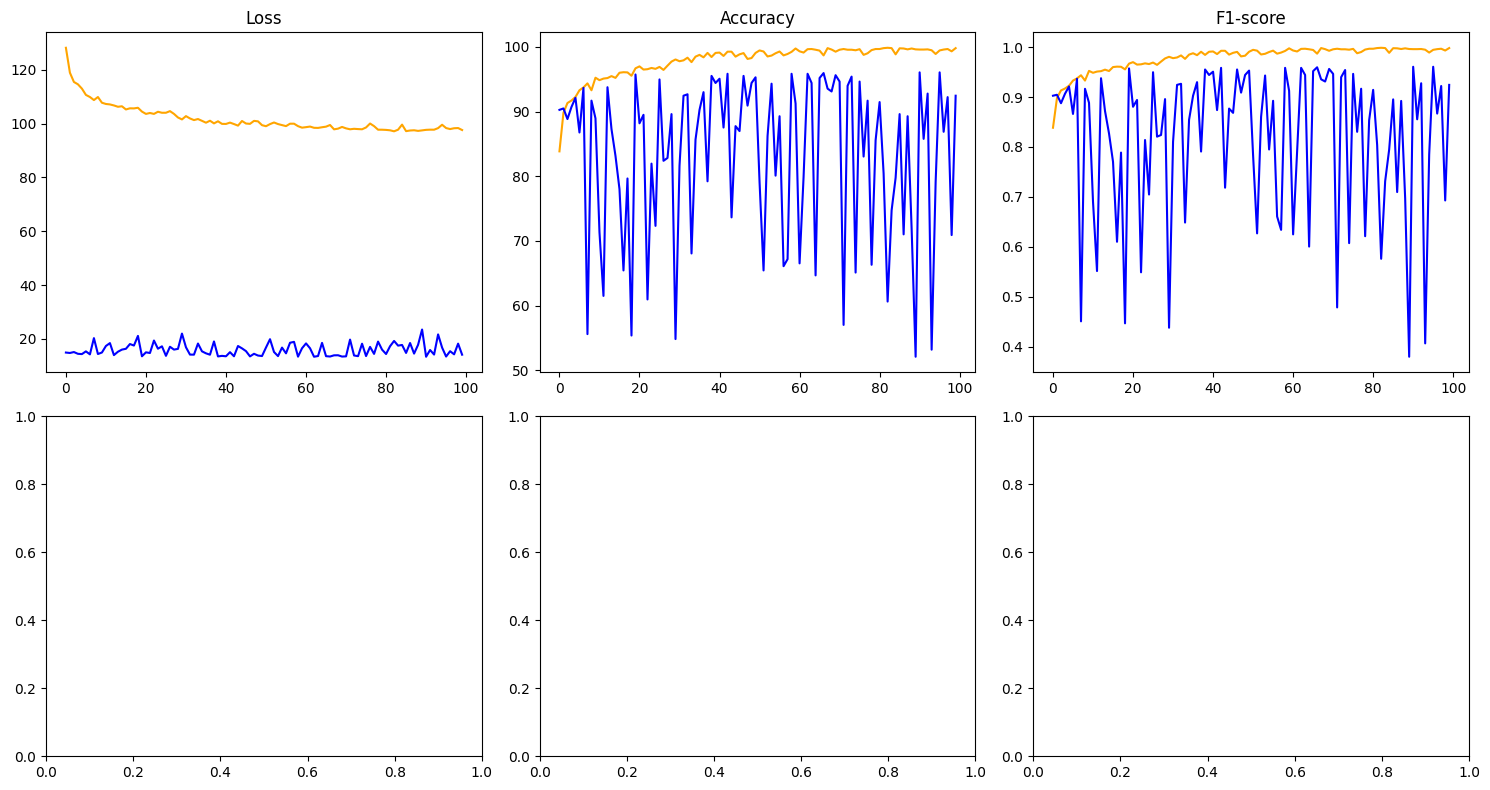

In [ ]:
# ============================================================
# EEG FEW-SHOT LEARNING FRAMEWORK
# Sobel + Attention + KAN + Deep Supervision
# Train/Validation + ROC + PR + IEEE Figures
# ============================================================

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from datetime import datetime

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve
)

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# LOAD DATA
# ============================================================

mat = sio.loadmat("SEED_VIG.mat")

X = mat["EEGsample"].astype(np.float32)
y = mat["substate"].squeeze()

X = (X - X.mean()) / (X.std() + 1e-6)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================================
# DATASET
# ============================================================

class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

train_loader = DataLoader(EEGDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader   = DataLoader(EEGDataset(X_val, y_val), batch_size=32, shuffle=False)

# ============================================================
# SOBEL PROJECTION
# ============================================================

class Sobel1D(nn.Module):
    def __init__(self):
        super().__init__()
        k = torch.tensor([[[-1, 0, 1]]], dtype=torch.float32)
        self.weight = nn.Parameter(k, requires_grad=False)

    def forward(self, x):
        B, C, T = x.shape
        out = []
        for c in range(C):
            out.append(F.conv1d(x[:, c:c+1], self.weight, padding=1))
        return torch.cat(out, dim=1).abs()

# ============================================================
# ATTENTION
# ============================================================

class Attention1D(nn.Module):
    def __init__(self, C, r=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(C, C // r)
        self.fc2 = nn.Linear(C // r, C)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        B, C, T = x.shape
        y = self.pool(x).view(B, C)
        y = F.relu(self.fc1(y))
        y = self.sigmoid(self.fc2(y)).view(B, C, 1)
        return x * y

# ============================================================
# KAN MIXER
# ============================================================

class KAN(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim * 2)
        self.fc2 = nn.Linear(dim * 2, dim)
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        r = x
        x = self.norm(x)
        x = F.gelu(self.fc1(x))
        x = self.fc2(x)
        return x + r

# ============================================================
# ENCODER
# ============================================================

class Encoder(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.sobel = Sobel1D()

        self.conv1 = nn.Conv1d(17, 32, 5, padding=2)
        self.conv2 = nn.Conv1d(32, 64, 5, padding=2)
        self.conv3 = nn.Conv1d(64, 128, 5, padding=2)

        self.bn1 = nn.BatchNorm1d(32)
        self.bn2 = nn.BatchNorm1d(64)
        self.bn3 = nn.BatchNorm1d(128)

        self.att1 = Attention1D(32)
        self.att2 = Attention1D(64)
        self.att3 = Attention1D(128)

        self.pool = nn.MaxPool1d(2)

        self.kan = KAN(128)

        self.ds1 = nn.Linear(32, num_classes)
        self.ds2 = nn.Linear(64, num_classes)
        self.ds3 = nn.Linear(128, num_classes)

    def forward(self, x):

        x = x + self.sobel(x)

        x1 = self.pool(self.att1(F.relu(self.bn1(self.conv1(x)))))
        x2 = self.pool(self.att2(F.relu(self.bn2(self.conv2(x1)))))
        x3 = self.pool(self.att3(F.relu(self.bn3(self.conv3(x2)))))

        f1 = F.adaptive_avg_pool1d(x1, 1).squeeze(-1)
        f2 = F.adaptive_avg_pool1d(x2, 1).squeeze(-1)
        f3 = F.adaptive_avg_pool1d(x3, 1).squeeze(-1)

        f3 = self.kan(f3)

        return f3, self.ds1(f1), self.ds2(f2), self.ds3(f3)

# ============================================================
# MODEL
# ============================================================

num_classes = len(np.unique(y))

class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = Encoder(num_classes)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        f, d1, d2, d3 = self.enc(x)
        return self.fc(f), [d1, d2, d3]

model = Model().to(device)

# ============================================================
# LOSS + OPT
# ============================================================

criterion = nn.CrossEntropyLoss(label_smoothing=0.3)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ============================================================
# HISTORY
# ============================================================

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "train_f1": [],
    "val_f1": []
}

# ============================================================
# TRAINING
# ============================================================

start_time = datetime.now()
num_epochs = 100

for epoch in range(num_epochs):

    # ================= TRAIN =================
    model.train()
    train_p, train_y = [], []
    train_loss = 0

    for x, yb in train_loader:
        x, yb = x.to(device), yb.to(device)

        optimizer.zero_grad()

        logits, ds = model(x)

        loss = criterion(logits, yb)
        for d in ds:
            loss += 0.3 * criterion(d, yb)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        train_p.extend(torch.argmax(logits, 1).cpu().numpy())
        train_y.extend(yb.cpu().numpy())

    # ================= VAL =================
    model.eval()
    val_p, val_y = [], []
    val_loss = 0

    with torch.no_grad():
        for x, yb in val_loader:
            x, yb = x.to(device), yb.to(device)

            logits, _ = model(x)

            loss = criterion(logits, yb)
            val_loss += loss.item()

            val_p.extend(torch.argmax(logits, 1).cpu().numpy())
            val_y.extend(yb.cpu().numpy())

    # ================= METRICS =================
    tr_acc = accuracy_score(train_y, train_p) * 100
    va_acc = accuracy_score(val_y, val_p) * 100

    tr_f1 = f1_score(train_y, train_p, average='weighted')
    va_f1 = f1_score(val_y, val_p, average='weighted')

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)
    history["train_f1"].append(tr_f1)
    history["val_f1"].append(va_f1)

    print(f"Epoch {epoch+1}/{num_epochs} - "
          f"Loss:{train_loss:.4f} "
          f"Train Acc:{tr_acc:.2f}% "
          f"Val Acc:{va_acc:.2f}% "
          f"Train F1:{tr_f1:.4f} "
          f"Val F1:{va_f1:.4f}")

print("Training time:", datetime.now() - start_time)

# ============================================================
# VISUALIZATION (BLUE=VAL, ORANGE=TRAIN)
# ============================================================

epochs = range(num_epochs)

fig, ax = plt.subplots(2, 3, figsize=(15, 8))

# LOSS
ax[0,0].plot(history["train_loss"], color='orange')
ax[0,0].plot(history["val_loss"], color='blue')
ax[0,0].set_title("Loss")

# ACC
ax[0,1].plot(history["train_acc"], color='orange')
ax[0,1].plot(history["val_acc"], color='blue')
ax[0,1].set_title("Accuracy")

# F1
ax[0,2].plot(history["train_f1"], color='orange')
ax[0,2].plot(history["val_f1"], color='blue')
ax[0,2].set_title("F1-score")

plt.tight_layout()
plt.show()